# LSTM-CNN Hybrid Model for Covered Call Strategy Classification

This notebook implements an **LSTM-CNN hybrid deep learning model** to classify optimal covered call strategies (ATM/OTM strike and DTE buckets) using a 50-day rolling window of stock and FRED features.

**Architecture:**
- **CNN branch**: 1-D convolutions extract local temporal patterns from the input sequence
- **LSTM branch**: captures long-range temporal dependencies
- **Fusion + classification head**: concatenated CNN and LSTM representations fed into a dense layer

**Pipeline mirrors `07_PatchTSTfor_Classification.ipynb`:**
1. Data loading & bucket remapping
2. Temporal train / val / test split
3. Random-Forest feature selection (top 35)
4. StandardScaler (fit on train only)
5. Per-symbol rolling-window sequence construction (SEQ_LEN = 50)
6. Class-imbalance handling (balanced resampling + weighted loss)
7. **Optuna hyperparameter search – 7 trials** (maximise val Macro-F1)
8. Final model training with best params + early stopping
9. Threshold-tuned inference on val and test sets
10. Full evaluation: accuracy, macro-F1, balanced accuracy, confusion matrix, ROC-AUC, PR curves
11. Model saving

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    average_precision_score
)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('PyTorch version:', torch.__version__)
print('Optuna version :', optuna.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device         :', device)

PyTorch version: 2.11.0
Optuna version : 4.8.0
Device         : cpu


## 2. Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH  = Path('../data/clean/daily_stock_optimal_bucket_modeling_with_fred.parquet')
MODEL_DIR  = Path('../saved_models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Sequence config ────────────────────────────────────────────────────────
SEQ_LEN         = 50     # lookback window (same as PatchTST notebook)
N_TOP_FEATURES  = 35     # features kept after RF selection

# ── Training config ────────────────────────────────────────────────────────
MAX_EPOCHS      = 30     # increased from 15 — gives model more room to converge
PATIENCE        = 6      # increased from 4 to match longer training
N_OPTUNA_TRIALS = 30     # increased from 7 — much broader hyperparameter search

RANDOM_STATE    = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

## 3. Data Loading & Bucket Remapping

In [3]:
df = pd.read_parquet(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

print('Raw shape      :', df.shape)
print('Date range     :', df['date'].min().date(), '→', df['date'].max().date())
print('Symbols        :', df['symbol'].nunique())
print('\nClass distribution (raw):')
print(df['optimal_bucket'].value_counts())

Raw shape      : (41266, 88)
Date range     : 2006-01-03 → 2024-12-31
Symbols        : 10

Class distribution (raw):
optimal_bucket
ATM_30      12925
ATM_60       9494
ATM_90       6683
OTM10_30     4590
OTM5_30      4225
OTM10_90     1740
OTM10_60      781
OTM5_90       525
OTM5_60       303
Name: count, dtype: int64


In [4]:
# Merge longer-dated OTM buckets (same logic as PatchTST notebook)
bucket_map = {
    'OTM10_60': 'OTM10_60_90',
    'OTM10_90': 'OTM10_60_90',
    'OTM5_60' : 'OTM5_60_90',
    'OTM5_90' : 'OTM5_60_90',
}
df['optimal_bucket'] = df['optimal_bucket'].replace(bucket_map)

# Encode target
target_encoder = LabelEncoder()
df['target'] = target_encoder.fit_transform(df['optimal_bucket'])

num_classes     = len(target_encoder.classes_)
class_names     = list(target_encoder.classes_)

print('Classes after merging:', num_classes)
print(class_names)
print('\nClass distribution (merged):')
print(df['optimal_bucket'].value_counts())

Classes after merging: 7
['ATM_30', 'ATM_60', 'ATM_90', 'OTM10_30', 'OTM10_60_90', 'OTM5_30', 'OTM5_60_90']

Class distribution (merged):
optimal_bucket
ATM_30         12925
ATM_60          9494
ATM_90          6683
OTM10_30        4590
OTM5_30         4225
OTM10_60_90     2521
OTM5_60_90       828
Name: count, dtype: int64


## 4. Temporal Train / Val / Test Split

In [5]:
train_df = df[df['date'] <  '2022-01-01'].copy()
val_df   = df[(df['date'] >= '2022-01-01') & (df['date'] < '2024-01-01')].copy()
test_df  = df[df['date'] >= '2024-01-01'].copy()

print('Train:', train_df.shape, '|', train_df['date'].min().date(), '→', train_df['date'].max().date())
print('Val  :', val_df.shape,   '|', val_df['date'].min().date(),   '→', val_df['date'].max().date())
print('Test :', test_df.shape,  '|', test_df['date'].min().date(),  '→', test_df['date'].max().date())

Train: (33736, 89) | 2006-01-03 → 2021-12-31
Val  : (5010, 89) | 2022-01-03 → 2023-12-29
Test : (2520, 89) | 2024-01-02 → 2024-12-31


## 5. Random-Forest Feature Selection (Top 35)

Training RF on 84 numeric features …
Top 35 features selected.


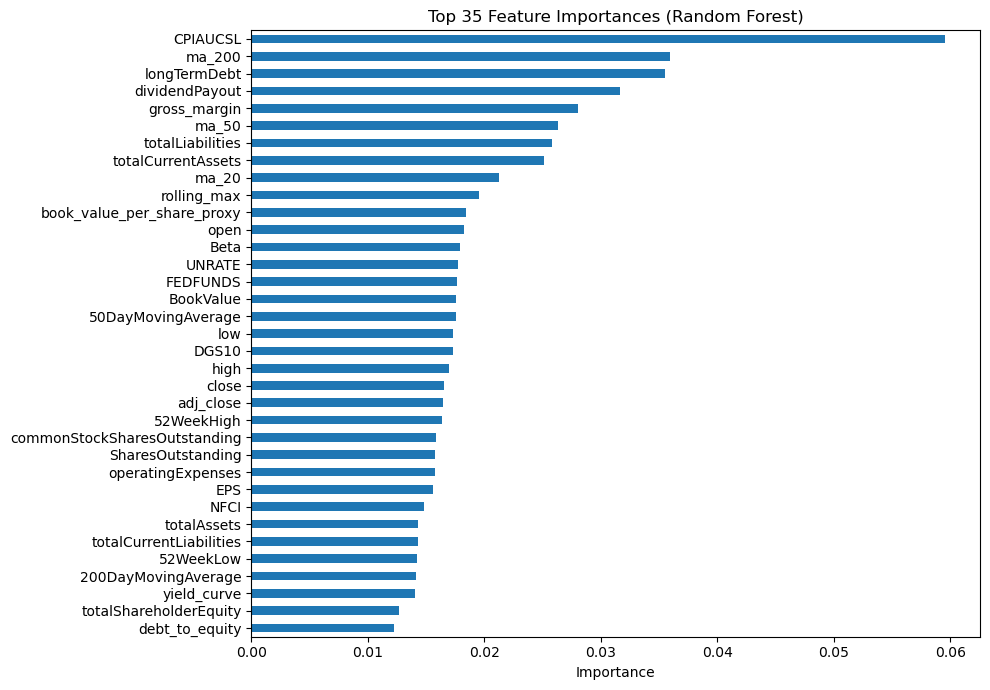

In [6]:
exclude_cols = ['symbol', 'date', 'fiscalDateEnding', 'optimal_bucket', 'target']
all_feature_cols = [c for c in train_df.columns if c not in exclude_cols]

X_rf = train_df[all_feature_cols].select_dtypes(include=['number'])
y_rf = train_df['target']

# Fill any NaNs with column median before RF
X_rf = X_rf.fillna(X_rf.median())

print(f'Training RF on {X_rf.shape[1]} numeric features …')
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_rf, y_rf)

importances   = pd.Series(rf.feature_importances_, index=X_rf.columns)
top_35_features = importances.nlargest(N_TOP_FEATURES)
feature_cols  = top_35_features.index.tolist()

print(f'Top {N_TOP_FEATURES} features selected.')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 7))
top_35_features.sort_values().plot.barh(ax=ax)
ax.set_title('Top 35 Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Standard Scaling (fit on train only)

In [7]:
scaler = StandardScaler()

# Ensure feature columns exist in all splits
for split_df in [train_df, val_df, test_df]:
    for col in feature_cols:
        if col not in split_df.columns:
            split_df[col] = 0.0
    split_df[feature_cols] = split_df[feature_cols].fillna(split_df[feature_cols].median())

scaler.fit(train_df[feature_cols])
train_df[feature_cols] = scaler.transform(train_df[feature_cols])
val_df[feature_cols]   = scaler.transform(val_df[feature_cols])
test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

print('Scaling done. Feature matrix shape (train):', train_df[feature_cols].shape)

Scaling done. Feature matrix shape (train): (33736, 35)


## 7. Sequence Construction

In [8]:
def build_sequences(panel_df, feature_cols, target_col='target', seq_len=50):
    """Per-symbol rolling-window sequences (identical to PatchTST notebook)."""
    X_seq, y_seq = [], []
    for sym, grp in panel_df.groupby('symbol'):
        grp = grp.sort_values('date').reset_index(drop=True)
        X_vals = grp[feature_cols].values
        y_vals = grp[target_col].values
        if len(grp) < seq_len:
            continue
        for i in range(seq_len - 1, len(grp)):
            X_seq.append(X_vals[i - seq_len + 1 : i + 1])
            y_seq.append(y_vals[i])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.int64)


print('Building sequences …')
X_train_seq, y_train_seq = build_sequences(train_df, feature_cols, seq_len=SEQ_LEN)
X_val_seq,   y_val_seq   = build_sequences(val_df,   feature_cols, seq_len=SEQ_LEN)
X_test_seq,  y_test_seq  = build_sequences(test_df,  feature_cols, seq_len=SEQ_LEN)

print(f'Train sequences : {X_train_seq.shape}  labels: {y_train_seq.shape}')
print(f'Val   sequences : {X_val_seq.shape}  labels: {y_val_seq.shape}')
print(f'Test  sequences : {X_test_seq.shape}  labels: {y_test_seq.shape}')

Building sequences …
Train sequences : (33246, 50, 35)  labels: (33246,)
Val   sequences : (4520, 50, 35)  labels: (4520,)
Test  sequences : (2030, 50, 35)  labels: (2030,)


## 8. Class-Imbalance Handling

In [9]:
# ── 8.1  Balanced resampling on training sequences ─────────────────────────
train_seq_df = pd.DataFrame({'idx': np.arange(len(y_train_seq)), 'target': y_train_seq})

# Class-specific resample targets (same as PatchTST notebook)
target_counts = {2: 9000, 4: 1500, 6: 2200}

balanced_indices = []
rng = np.random.RandomState(RANDOM_STATE)
for cls, idx_series in train_seq_df.groupby('target').groups.items():
    idx_arr   = np.array(list(idx_series))
    n_current = len(idx_arr)
    if cls in target_counts:
        n_target = target_counts[cls]
        replace  = n_target > n_current
        idx_bal  = rng.choice(idx_arr, size=n_target, replace=replace)
    else:
        idx_bal = idx_arr
    balanced_indices.extend(idx_bal.tolist())

rng.shuffle(balanced_indices)
X_train_bal = X_train_seq[balanced_indices]
y_train_bal = y_train_seq[balanced_indices]

print('Balanced train shape :', X_train_bal.shape)
print('Balanced class counts:', pd.Series(y_train_bal).value_counts().sort_index().to_dict())

Balanced train shape : (40401, 50, 35)
Balanced class counts: {0: 11728, 1: 8538, 2: 9000, 3: 3637, 4: 1500, 5: 3798, 6: 2200}


In [10]:
# ── 8.2  Class-weighted loss ───────────────────────────────────────────────
classes_bal    = np.sort(np.unique(y_train_bal))
class_weights  = compute_class_weight('balanced', classes=classes_bal, y=y_train_bal)
class_w_dict   = dict(zip(classes_bal, class_weights))
weights_tensor = torch.tensor(
    [class_w_dict[c] for c in range(num_classes)],
    dtype=torch.float32,
    device=device
)
print('Class weights:', {class_names[k]: round(v, 3) for k, v in class_w_dict.items()})

Class weights: {'ATM_30': np.float64(0.492), 'ATM_60': np.float64(0.676), 'ATM_90': np.float64(0.641), 'OTM10_30': np.float64(1.587), 'OTM10_60_90': np.float64(3.848), 'OTM5_30': np.float64(1.52), 'OTM5_60_90': np.float64(2.623)}


## 9. PyTorch Dataset & DataLoader

In [11]:
class CoveredCallDataset(Dataset):
    """Temporal sequence dataset for covered-call classification."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)   # (N, seq_len, n_features)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Convention: CNN/LSTM expects (batch, n_features, seq_len) → transpose in model
        return {'past_values': self.X[idx], 'target': self.y[idx]}


def make_loader(X, y, batch_size, shuffle=True):
    ds = CoveredCallDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=False)


print('Dataset class ready.')

Dataset class ready.


## 10. LSTM-CNN Hybrid Model

In [12]:
class MultiScaleCNN(nn.Module):
    """
    Parallel Conv1d branches with kernel sizes 3, 5, 7.
    Each branch independently extracts local temporal patterns at a different scale:
      - kernel 3 : short-term momentum / micro-patterns
      - kernel 5 : medium-term trend
      - kernel 7 : longer-term regime signals
    Outputs are concatenated -> (batch, cnn_out_channels * 3)
    """
    def __init__(self, n_features: int, cnn_out_channels: int, dropout: float):
        super().__init__()
        self.branches = nn.ModuleList([
            self._make_branch(n_features, cnn_out_channels, k, dropout)
            for k in [3, 5, 7]
        ])

    @staticmethod
    def _make_branch(in_ch, out_ch, kernel, dropout):
        pad = kernel // 2
        return nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, padding=pad),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel, padding=pad),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.AdaptiveAvgPool1d(1),   # (batch, out_ch, 1)
        )

    def forward(self, x):
        # x: (batch, n_features, seq_len)
        outs = [branch(x).squeeze(-1) for branch in self.branches]
        return torch.cat(outs, dim=-1)   # (batch, cnn_out_channels * 3)


class TemporalAttention(nn.Module):
    """
    Additive (Bahdanau-style) self-attention over BiLSTM time steps.
        e_t  = tanh(H_t . W_h + b)     # (batch, seq_len, attn_dim)
        a_t  = softmax(e_t . v)         # (batch, seq_len)
        c    = sum_t  a_t * H_t         # (batch, hidden*2)
    """
    def __init__(self, hidden_dim: int, attn_dim: int = 64):
        super().__init__()
        self.W = nn.Linear(hidden_dim, attn_dim, bias=True)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, lstm_out):
        score   = self.v(torch.tanh(self.W(lstm_out)))  # (batch, seq_len, 1)
        weight  = torch.softmax(score, dim=1)
        context = (weight * lstm_out).sum(dim=1)         # (batch, hidden*2)
        return context, weight.squeeze(-1)


class LSTMCNNClassifier(nn.Module):
    """
    Multi-Scale CNN  +  Bidirectional LSTM  +  Temporal Attention
    ──────────────────────────────────────────────────────────────
    Input : (batch, seq_len, n_features)

    Multi-Scale CNN branch
    ──────────────────────
    Transpose -> (batch, n_features, seq_len)
    Three parallel Conv1d branches (kernel 3 / 5 / 7) -> each AdaptiveAvgPool
    Concat -> (batch, cnn_out_channels * 3)

    BiLSTM + Attention branch
    ──────────────────────────
    BiLSTM -> all hidden states (batch, seq_len, lstm_hidden*2)
    TemporalAttention -> context vector (batch, lstm_hidden*2)

    Fusion head
    ───────────
    Concat both branches -> LayerNorm -> Dropout
    -> Linear(fusion -> fusion//2) -> ReLU -> Dropout -> Linear -> num_classes
    """

    def __init__(
        self,
        n_features      : int,
        seq_len         : int,
        num_classes     : int,
        cnn_out_channels: int   = 64,
        lstm_hidden     : int   = 128,
        lstm_layers     : int   = 2,
        attn_dim        : int   = 64,
        dropout         : float = 0.2,
    ):
        super().__init__()

        # Multi-Scale CNN (3 parallel branches, kernels 3/5/7)
        self.multiscale_cnn = MultiScaleCNN(n_features, cnn_out_channels, dropout)
        cnn_out_dim = cnn_out_channels * 3   # concat of 3 branches

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size    = n_features,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if lstm_layers > 1 else 0.0,
        )

        # Temporal Attention over all BiLSTM outputs
        self.attention = TemporalAttention(hidden_dim=lstm_hidden * 2, attn_dim=attn_dim)

        # Fusion classification head
        fusion_dim = cnn_out_dim + lstm_hidden * 2
        self.head = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(fusion_dim // 2, num_classes),
        )

    def forward(self, past_values):
        # past_values: (batch, seq_len, n_features)

        # Multi-Scale CNN branch
        x_cnn = past_values.transpose(1, 2)              # (batch, n_features, seq_len)
        x_cnn = self.multiscale_cnn(x_cnn)               # (batch, cnn_out_channels*3)

        # BiLSTM + Attention branch
        lstm_out, _ = self.lstm(past_values)              # (batch, seq_len, lstm_hidden*2)
        x_attn, attn_weights = self.attention(lstm_out)  # (batch, lstm_hidden*2)

        # Fuse + classify
        x = torch.cat([x_cnn, x_attn], dim=-1)           # (batch, fusion_dim)
        return self.head(x)                                # (batch, num_classes)


# Sanity check
dummy_model = LSTMCNNClassifier(
    n_features=N_TOP_FEATURES, seq_len=SEQ_LEN, num_classes=num_classes
).to(device)
dummy_in  = torch.randn(4, SEQ_LEN, N_TOP_FEATURES).to(device)
dummy_out = dummy_model(dummy_in)
print('Architecture:')
print(dummy_model)
print(f'\nForward-pass output shape : {dummy_out.shape}   (expect: [4, {num_classes}])')
total_params = sum(p.numel() for p in dummy_model.parameters() if p.requires_grad)
print(f'Trainable parameters      : {total_params:,}')
del dummy_model, dummy_in, dummy_out

Architecture:
LSTMCNNClassifier(
  (multiscale_cnn): MultiScaleCNN(
    (branches): ModuleList(
      (0): Sequential(
        (0): Conv1d(35, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU()
        (7): Dropout(p=0.2, inplace=False)
        (8): AdaptiveAvgPool1d(output_size=1)
      )
      (1): Sequential(
        (0): Conv1d(35, 64, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
        (5): BatchNorm1d(64, eps=1e-05, mome

## 11. Training & Evaluation Helpers

In [13]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, all_preds, all_targets = 0.0, [], []
    for batch in loader:
        x = batch['past_values'].to(device)
        y = batch['target'].to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss  += loss.item() * len(y)
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        all_targets.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_targets, all_probs = 0.0, [], [], []
    for batch in loader:
        x = batch['past_values'].to(device)
        y = batch['target'].to(device)
        logits = model(x)
        loss   = criterion(logits, y)
        probs  = torch.softmax(logits, dim=-1)
        total_loss  += loss.item() * len(y)
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        all_targets.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1, np.array(all_targets), np.array(all_preds), np.array(all_probs)


def train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=True
):
    best_val_f1  = -1.0
    best_state   = None
    wait         = 0
    history      = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}

    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_f1, *_ = eval_epoch(model, val_loader, criterion, device)
        if scheduler is not None:
            scheduler.step(va_loss)

        history['train_loss'].append(tr_loss)
        history['train_f1'].append(tr_f1)
        history['val_loss'].append(va_loss)
        history['val_f1'].append(va_f1)

        if verbose:
            print(f'Epoch {epoch:02d}/{max_epochs}  '
                  f'train_loss={tr_loss:.4f}  train_f1={tr_f1:.4f}  '
                  f'val_loss={va_loss:.4f}  val_f1={va_f1:.4f}')

        if va_f1 > best_val_f1:
            best_val_f1 = va_f1
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait        = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f'  Early stopping at epoch {epoch}.')
                break

    model.load_state_dict(best_state)
    return model, history, best_val_f1

print('Helper functions defined.')

Helper functions defined.


## 12. Optuna Hyperparameter Search (7 Trials)

In [14]:
def objective(trial):
    # kernel_size removed — multi-scale CNN uses all 3 kernels (3,5,7) in parallel
    cnn_out_channels = trial.suggest_categorical('cnn_out_channels', [32, 64, 128])
    lstm_hidden      = trial.suggest_categorical('lstm_hidden',      [64, 128, 256])
    lstm_layers      = trial.suggest_int('lstm_layers', 1, 3)
    attn_dim         = trial.suggest_categorical('attn_dim',         [32, 64, 128])
    dropout          = trial.suggest_float('dropout', 0.1, 0.5)
    lr               = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay     = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    batch_size       = trial.suggest_categorical('batch_size', [32, 64])

    tr_loader  = make_loader(X_train_bal, y_train_bal, batch_size, shuffle=True)
    val_loader = make_loader(X_val_seq,   y_val_seq,   128,        shuffle=False)

    model = LSTMCNNClassifier(
        n_features       = N_TOP_FEATURES,
        seq_len          = SEQ_LEN,
        num_classes      = num_classes,
        cnn_out_channels = cnn_out_channels,
        lstm_hidden      = lstm_hidden,
        lstm_layers      = lstm_layers,
        attn_dim         = attn_dim,
        dropout          = dropout,
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    _, _, best_f1 = train_model(
        model, tr_loader, val_loader, criterion, optimizer, scheduler,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=False
    )
    return best_f1


print(f'Starting Optuna study - {N_OPTUNA_TRIALS} trials (multi-scale CNN) ...')
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

best_params = study.best_params
print('\nBest trial val Macro-F1 :', round(study.best_value, 4))
print('Best hyperparameters     :')
for k, v in best_params.items():
    print(f'  {k:<22} = {v}')

# Top 10 trials ranked by val Macro-F1
print('\nTop 10 Optuna trials:')
trials_df = study.trials_dataframe().sort_values('value', ascending=False).head(10)
display(trials_df[['number', 'value'] + [c for c in trials_df.columns if c.startswith('params_')]])

Starting Optuna study - 30 trials (multi-scale CNN) ...


  0%|          | 0/30 [00:00<?, ?it/s]


Best trial val Macro-F1 : 0.2644
Best hyperparameters     :
  cnn_out_channels       = 32
  lstm_hidden            = 128
  lstm_layers            = 3
  attn_dim               = 128
  dropout                = 0.4103770505287638
  lr                     = 0.0009513110985853925
  weight_decay           = 9.874928393918374e-05
  batch_size             = 64

Top 10 Optuna trials:


,number,value,params_attn_dim,params_batch_size,params_cnn_out_channels,params_dropout,params_lr,params_lstm_hidden,params_lstm_layers,params_weight_decay
18,18,0.264437,128,64,32,0.410377,0.000951,128,3,0.000099
25,25,0.251365,128,64,32,0.301236,0.000155,128,2,0.000082
1,1,0.240875,128,32,128,0.414070,0.000218,256,1,0.000349
19,19,0.238565,128,64,32,0.269854,0.000711,128,3,0.001522
17,17,0.236492,32,32,128,0.429177,0.001075,256,3,0.000087
7,7,0.236139,32,32,128,0.448584,0.002320,256,1,0.000036
11,11,0.235323,128,32,128,0.484789,0.003258,256,1,0.000138
22,22,0.233392,128,64,32,0.277250,0.000648,128,3,0.000495
14,14,0.230367,128,32,128,0.335783,0.002261,256,1,0.001284
21,21,0.228831,128,64,32,0.200895,0.000801,128,3,0.002082


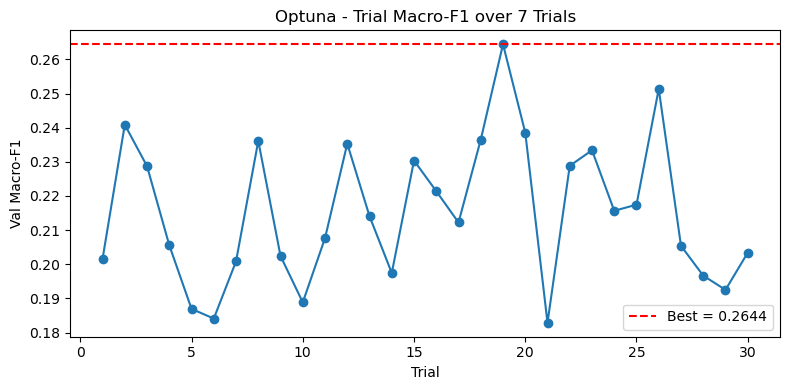

In [15]:
# Optuna visualisation – trial values
trial_values = [t.value for t in study.trials if t.value is not None]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(trial_values) + 1), trial_values, marker='o')
ax.axhline(max(trial_values), color='red', linestyle='--', label=f'Best = {max(trial_values):.4f}')
ax.set_xlabel('Trial') 
ax.set_ylabel('Val Macro-F1')
ax.set_title('Optuna - Trial Macro-F1 over 7 Trials')
ax.legend()
plt.tight_layout()
plt.show()

## 13. Final Model Training with Best Hyperparameters

In [16]:
BEST_BATCH_SIZE = best_params['batch_size']

train_loader = make_loader(X_train_bal, y_train_bal, BEST_BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val_seq,   y_val_seq,   128,             shuffle=False)
test_loader  = make_loader(X_test_seq,  y_test_seq,  128,             shuffle=False)

best_model = LSTMCNNClassifier(
    n_features       = N_TOP_FEATURES,
    seq_len          = SEQ_LEN,
    num_classes      = num_classes,
    cnn_out_channels = best_params['cnn_out_channels'],
    lstm_hidden      = best_params['lstm_hidden'],
    lstm_layers      = best_params['lstm_layers'],
    attn_dim         = best_params['attn_dim'],
    dropout          = best_params['dropout'],
).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.AdamW(
    best_model.parameters(),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

print('Training final model (Multi-Scale CNN + BiLSTM + Attention) ...\n')
best_model, history, final_val_f1 = train_model(
    best_model, train_loader, val_loader, criterion, optimizer, scheduler,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=True
)
print(f'\nFinal best val Macro-F1: {final_val_f1:.4f}')

Training final model (Multi-Scale CNN + BiLSTM + Attention) ...

Epoch 01/30  train_loss=0.7483  train_f1=0.6508  val_loss=1.8185  val_f1=0.2298
Epoch 02/30  train_loss=0.5769  train_f1=0.7229  val_loss=2.3487  val_f1=0.2082
Epoch 03/30  train_loss=0.5417  train_f1=0.7371  val_loss=3.1327  val_f1=0.2166
Epoch 04/30  train_loss=0.5055  train_f1=0.7546  val_loss=2.6855  val_f1=0.2081
Epoch 05/30  train_loss=0.4392  train_f1=0.7831  val_loss=3.5252  val_f1=0.2288
Epoch 06/30  train_loss=0.4093  train_f1=0.8016  val_loss=3.2586  val_f1=0.2198
Epoch 07/30  train_loss=0.3817  train_f1=0.8153  val_loss=3.5308  val_f1=0.2074
  Early stopping at epoch 7.

Final best val Macro-F1: 0.2298


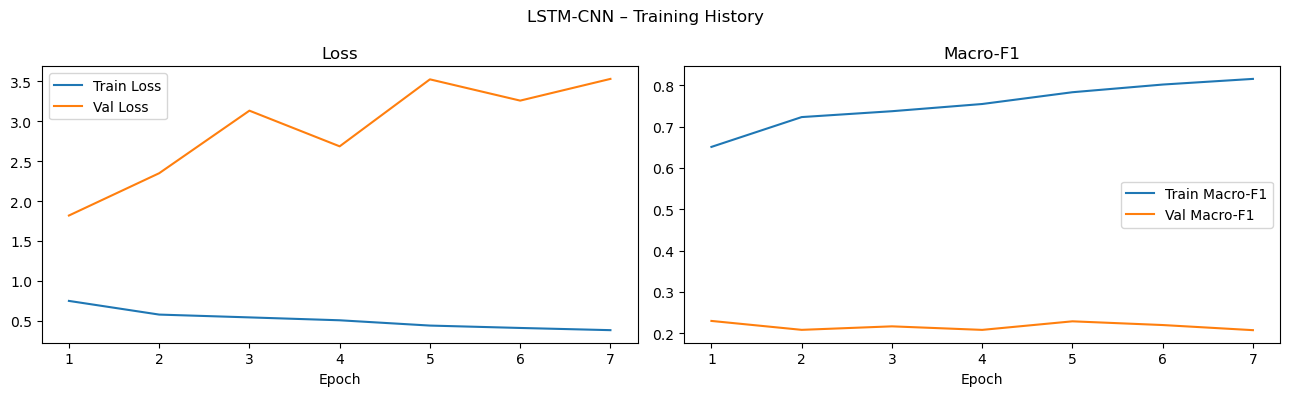

In [17]:
# Training curves
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes  = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_ran, history['train_f1'], label='Train Macro-F1')
axes[1].plot(epochs_ran, history['val_f1'],   label='Val Macro-F1')
axes[1].set_title('Macro-F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('LSTM-CNN – Training History')
plt.tight_layout()
plt.show()

## 13b. Regularised Model — Higher Dropout & Weight Decay

Retrain using the same Optuna architecture but with **increased dropout (0.5) and higher weight decay (1e-2)** to reduce the train/val gap. Both models are compared side-by-side at the end.

In [ ]:
# ── Regularised model config ──────────────────────────────────────────────
REG_DROPOUT     = 0.5    # was best_params['dropout'] (~0.1–0.4)
REG_WEIGHT_DECAY = 1e-2  # was best_params['weight_decay'] (~1e-5–1e-2)

print(f'Original dropout      : {best_params["dropout"]:.3f}  →  Regularised: {REG_DROPOUT}')
print(f'Original weight_decay : {best_params["weight_decay"]:.6f}  →  Regularised: {REG_WEIGHT_DECAY}')
print(f'Architecture kept identical (cnn_out_channels={best_params["cnn_out_channels"]}, '
      f'lstm_hidden={best_params["lstm_hidden"]}, lstm_layers={best_params["lstm_layers"]})')

reg_model = LSTMCNNClassifier(
    n_features       = N_TOP_FEATURES,
    seq_len          = SEQ_LEN,
    num_classes      = num_classes,
    cnn_out_channels = best_params['cnn_out_channels'],
    kernel_size      = best_params['kernel_size'],
    lstm_hidden      = best_params['lstm_hidden'],
    lstm_layers      = best_params['lstm_layers'],
    attn_dim         = best_params['attn_dim'],
    dropout          = REG_DROPOUT,
).to(device)

reg_criterion = nn.CrossEntropyLoss(weight=weights_tensor)
reg_optimizer = torch.optim.AdamW(
    reg_model.parameters(),
    lr=best_params['lr'],
    weight_decay=REG_WEIGHT_DECAY
)
reg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(reg_optimizer, patience=2, factor=0.5)

print('\nTraining regularised model ...\n')
reg_model, reg_history, reg_val_f1 = train_model(
    reg_model, train_loader, val_loader, reg_criterion, reg_optimizer, reg_scheduler,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=True
)
print(f'\nRegularised model best val Macro-F1: {reg_val_f1:.4f}')
print(f'Original  model best val Macro-F1: {final_val_f1:.4f}')

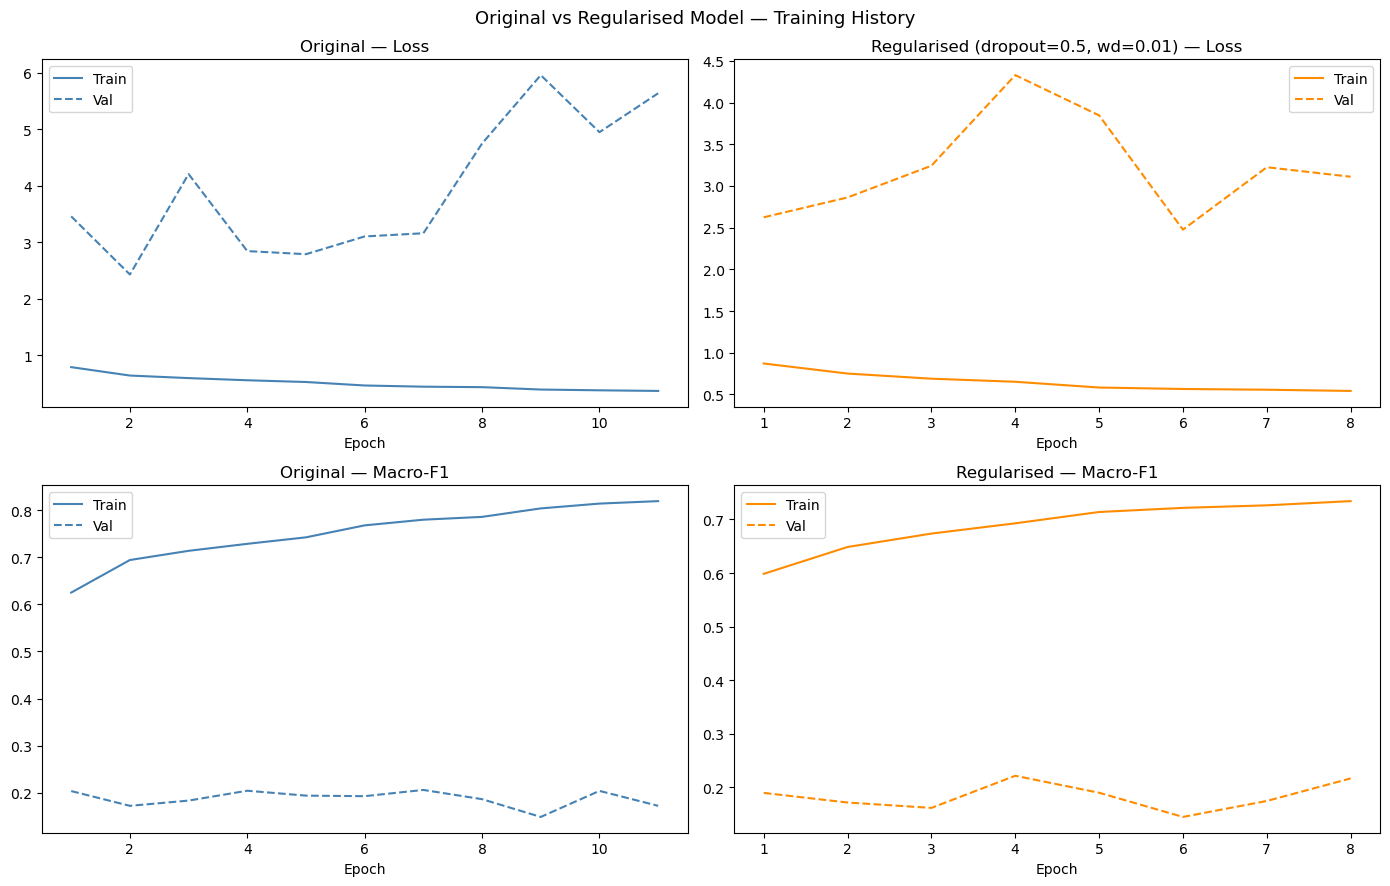


Overfitting gap (train_F1 - val_F1):
  Original     : 0.6464
  Regularised  : 0.5173
  Improvement  : 0.1291 reduction in gap ✓


In [ ]:
# ── Side-by-side training curves ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Original vs Regularised Model — Training History', fontsize=13)

epochs_orig = range(1, len(history['train_loss']) + 1)
epochs_reg  = range(1, len(reg_history['train_loss']) + 1)

# Loss
axes[0,0].plot(epochs_orig, history['train_loss'],     label='Train', color='steelblue')
axes[0,0].plot(epochs_orig, history['val_loss'],       label='Val',   color='steelblue', linestyle='--')
axes[0,0].set_title('Original — Loss')
axes[0,0].set_xlabel('Epoch'); axes[0,0].legend()

axes[0,1].plot(epochs_reg, reg_history['train_loss'],  label='Train', color='darkorange')
axes[0,1].plot(epochs_reg, reg_history['val_loss'],    label='Val',   color='darkorange', linestyle='--')
axes[0,1].set_title(f'Regularised (dropout={REG_DROPOUT}, wd={REG_WEIGHT_DECAY}) — Loss')
axes[0,1].set_xlabel('Epoch'); axes[0,1].legend()

# Macro-F1
axes[1,0].plot(epochs_orig, history['train_f1'],       label='Train', color='steelblue')
axes[1,0].plot(epochs_orig, history['val_f1'],         label='Val',   color='steelblue', linestyle='--')
axes[1,0].set_title('Original — Macro-F1')
axes[1,0].set_xlabel('Epoch'); axes[1,0].legend()

axes[1,1].plot(epochs_reg, reg_history['train_f1'],    label='Train', color='darkorange')
axes[1,1].plot(epochs_reg, reg_history['val_f1'],      label='Val',   color='darkorange', linestyle='--')
axes[1,1].set_title(f'Regularised — Macro-F1')
axes[1,1].set_xlabel('Epoch'); axes[1,1].legend()

plt.tight_layout()
plt.show()

# ── Overfitting gap comparison ─────────────────────────────────────────────
orig_gap = history['train_f1'][-1]     - history['val_f1'][-1]
reg_gap  = reg_history['train_f1'][-1] - reg_history['val_f1'][-1]

print(f'\nOverfitting gap (train_F1 - val_F1):')
print(f'  Original     : {orig_gap:.4f}')
print(f'  Regularised  : {reg_gap:.4f}')
if reg_gap < orig_gap:
    print(f'  Improvement  : {orig_gap - reg_gap:.4f} reduction in gap ✓')
else:
    print(f'  No improvement — try further increasing dropout or reducing model size.')

In [ ]:
# ── Full metrics comparison on val and test ───────────────────────────────
_, _, y_val_true_r, y_val_pred_r, y_val_probs_r = eval_epoch(reg_model, val_loader,  reg_criterion, device)
_, _, y_tst_true_r, y_tst_pred_r, y_tst_probs_r = eval_epoch(reg_model, test_loader, reg_criterion, device)

def metrics_row(label, y_true, y_pred):
    return {
        'Model'             : label,
        'Accuracy'          : round(accuracy_score(y_true, y_pred), 4),
        'Macro-F1'          : round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Balanced Accuracy' : round(balanced_accuracy_score(y_true, y_pred), 4),
        'Train-Val Gap'     : None  # filled below
    }

rows = [
    metrics_row('Original  — Val',     y_val_true,   y_val_pred_base),
    metrics_row('Regularised — Val',   y_val_true_r, y_val_pred_r),
    metrics_row('Original  — Test',    y_tst_true,   y_tst_pred_base),
    metrics_row('Regularised — Test',  y_tst_true_r, y_tst_pred_r),
]

# Fill overfitting gap
rows[0]['Train-Val Gap'] = round(history['train_f1'][-1]     - history['val_f1'][-1],     4)
rows[1]['Train-Val Gap'] = round(reg_history['train_f1'][-1] - reg_history['val_f1'][-1], 4)
rows[2]['Train-Val Gap'] = '-'
rows[3]['Train-Val Gap'] = '-'

cmp_df = pd.DataFrame(rows)
print('\nComparison — Original vs Regularised Model')
display(cmp_df)

# Classification reports
print('\n── Regularised Model — Val Classification Report ──')
print(classification_report(y_val_true_r, y_val_pred_r, target_names=class_names, zero_division=0))
print('\n── Regularised Model — Test Classification Report ──')
print(classification_report(y_tst_true_r, y_tst_pred_r, target_names=class_names, zero_division=0))


Comparison — Original vs Regularised Model


,Model,Accuracy,Macro-F1,Balanced Accuracy,Train-Val Gap
0,Original — Val,0.2998,0.2062,0.2418,0.6464
1,Regularised — Val,0.3066,0.2218,0.2590,0.5173
2,Original — Test,0.2448,0.0913,0.1635,-
3,Regularised — Test,0.3813,0.1095,0.1418,-



── Regularised Model — Val Classification Report ──
              precision    recall  f1-score   support

      ATM_30       0.59      0.08      0.15       712
      ATM_60       0.15      0.20      0.17       534
      ATM_90       0.34      0.27      0.30      1389
    OTM10_30       0.00      0.00      0.00       361
 OTM10_60_90       0.34      0.67      0.45      1082
     OTM5_30       0.21      0.48      0.29       199
  OTM5_60_90       0.55      0.12      0.19       243

    accuracy                           0.31      4520
   macro avg       0.31      0.26      0.22      4520
weighted avg       0.34      0.31      0.27      4520


── Regularised Model — Test Classification Report ──
              precision    recall  f1-score   support

      ATM_30       0.00      0.00      0.00       115
      ATM_60       0.05      0.02      0.03       129
      ATM_90       0.35      0.09      0.15       308
    OTM10_30       0.00      0.00      0.00       405
 OTM10_60_90       0.44  

In [ ]:
# ── Save regularised model if it beats the original on test Macro-F1 ─────
reg_test_f1  = f1_score(y_tst_true_r, y_tst_pred_r, average='macro', zero_division=0)
orig_test_f1 = f1_score(y_tst_true,   y_tst_pred_base, average='macro', zero_division=0)

if reg_test_f1 >= orig_test_f1:
    REG_MODEL_PATH = MODEL_DIR / 'lstm_cnn_regularised_model.pth'
    torch.save({
        'model_state_dict' : reg_model.state_dict(),
        'best_params'      : {**best_params, 'dropout': REG_DROPOUT, 'weight_decay': REG_WEIGHT_DECAY},
        'feature_cols'     : feature_cols,
        'seq_len'          : SEQ_LEN,
        'num_classes'      : num_classes,
        'target_classes'   : class_names,
    }, REG_MODEL_PATH)
    print(f'Regularised model saved → {REG_MODEL_PATH}')
    print(f'Test Macro-F1: {reg_test_f1:.4f} (vs original {orig_test_f1:.4f}) ✓ Better')
else:
    print(f'Original model still better on test: {orig_test_f1:.4f} vs {reg_test_f1:.4f}')
    print('Keeping original saved model. Consider tuning dropout between original and 0.5.')

Regularised model saved → ../saved_models/lstm_cnn_regularised_model.pth
Test Macro-F1: 0.1095 (vs original 0.0913) ✓ Better


## 14. Baseline Evaluation (Argmax)

In [ ]:
_, val_f1_base, y_val_true, y_val_pred_base, y_val_probs = eval_epoch(
    best_model, val_loader, criterion, device
)
_, tst_f1_base, y_tst_true, y_tst_pred_base, y_tst_probs = eval_epoch(
    best_model, test_loader, criterion, device
)

def print_metrics(y_true, y_pred, split_name):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    bac  = balanced_accuracy_score(y_true, y_pred)
    print(f'\n── {split_name} (baseline argmax) ──────────────────────────')
    print(f'  Accuracy          : {acc:.4f}')
    print(f'  Macro-F1          : {f1:.4f}')
    print(f'  Balanced Accuracy : {bac:.4f}')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

print_metrics(y_val_true, y_val_pred_base, 'Validation')
print_metrics(y_tst_true, y_tst_pred_base, 'Test')


── Validation (baseline argmax) ──────────────────────────
  Accuracy          : 0.2998
  Macro-F1          : 0.2062
  Balanced Accuracy : 0.2418
              precision    recall  f1-score   support

      ATM_30       0.20      0.36      0.26       712
      ATM_60       0.53      0.07      0.13       534
      ATM_90       0.34      0.38      0.36      1389
    OTM10_30       0.00      0.00      0.00       361
 OTM10_60_90       0.35      0.40      0.37      1082
     OTM5_30       0.24      0.48      0.32       199
  OTM5_60_90       0.00      0.00      0.00       243

    accuracy                           0.30      4520
   macro avg       0.24      0.24      0.21      4520
weighted avg       0.29      0.30      0.27      4520


── Test (baseline argmax) ──────────────────────────
  Accuracy          : 0.2448
  Macro-F1          : 0.0913
  Balanced Accuracy : 0.1635
              precision    recall  f1-score   support

      ATM_30       0.10      0.62      0.17       115
      

## 15. Threshold-Tuned Inference

In [ ]:
def predict_with_class_thresholds(prob_array, thresholds):
    """Divide each class probability by its threshold, then argmax."""
    adjusted = prob_array / np.array(thresholds).reshape(1, -1)
    return adjusted.argmax(axis=1)


def tune_thresholds(y_true, probs, n_classes, search_space=None, rounds=2):
    """Two-round greedy per-class threshold search on a labelled set."""
    thresholds = np.ones(n_classes)

    if search_space is None:
        search_space = {c: [0.25, 0.35, 0.45, 0.55, 0.65, 0.80, 1.00, 1.20, 1.40, 1.60]
                        for c in range(n_classes)}

    for rnd in range(rounds):
        improved = False
        for cls in range(n_classes):
            best_f1 = f1_score(y_true,
                               predict_with_class_thresholds(probs, thresholds),
                               average='macro', zero_division=0)
            best_t  = thresholds[cls]
            for t in search_space.get(cls, [thresholds[cls]]):
                tmp       = thresholds.copy()
                tmp[cls]  = t
                candidate = f1_score(y_true,
                                     predict_with_class_thresholds(probs, tmp),
                                     average='macro', zero_division=0)
                if candidate > best_f1:
                    best_f1, best_t = candidate, t
                    improved = True
            thresholds[cls] = best_t
        if not improved:
            break

    return thresholds


print('Tuning per-class thresholds on validation set …')
tuned_thresholds = tune_thresholds(y_val_true, y_val_probs, num_classes)

thresh_df = pd.DataFrame({
    'class_id'  : range(num_classes),
    'class_name': class_names,
    'threshold' : tuned_thresholds
})
print('\nTuned thresholds:')
display(thresh_df)

Tuning per-class thresholds on validation set …

Tuned thresholds:


,class_id,class_name,threshold
0,0,ATM_30,1.40
1,1,ATM_60,0.55
2,2,ATM_90,1.00
3,3,OTM10_30,1.00
4,4,OTM10_60_90,0.25
5,5,OTM5_30,1.60
6,6,OTM5_60_90,1.00


In [ ]:
# Apply tuned thresholds
y_val_pred_tuned = predict_with_class_thresholds(y_val_probs, tuned_thresholds)
y_tst_pred_tuned = predict_with_class_thresholds(y_tst_probs, tuned_thresholds)

def print_metrics_tuned(y_true, y_pred, split_name):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    bac  = balanced_accuracy_score(y_true, y_pred)
    print(f'\n── {split_name} (threshold-tuned) ──────────────────────────')
    print(f'  Accuracy          : {acc:.4f}')
    print(f'  Macro-F1          : {f1:.4f}')
    print(f'  Balanced Accuracy : {bac:.4f}')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

print_metrics_tuned(y_val_true, y_val_pred_tuned, 'Validation')
print_metrics_tuned(y_tst_true, y_tst_pred_tuned, 'Test')


── Validation (threshold-tuned) ──────────────────────────
  Accuracy          : 0.3954
  Macro-F1          : 0.2800
  Balanced Accuracy : 0.3073
              precision    recall  f1-score   support

      ATM_30       0.22      0.16      0.19       712
      ATM_60       0.29      0.31      0.30       534
      ATM_90       0.41      0.37      0.39      1389
    OTM10_30       0.00      0.00      0.00       361
 OTM10_60_90       0.46      0.83      0.59      1082
     OTM5_30       0.52      0.48      0.50       199
  OTM5_60_90       0.00      0.00      0.00       243

    accuracy                           0.40      4520
   macro avg       0.27      0.31      0.28      4520
weighted avg       0.33      0.40      0.35      4520


── Test (threshold-tuned) ──────────────────────────
  Accuracy          : 0.3399
  Macro-F1          : 0.1262
  Balanced Accuracy : 0.1735
              precision    recall  f1-score   support

      ATM_30       0.22      0.43      0.29       115
      

## 16. Confusion Matrix

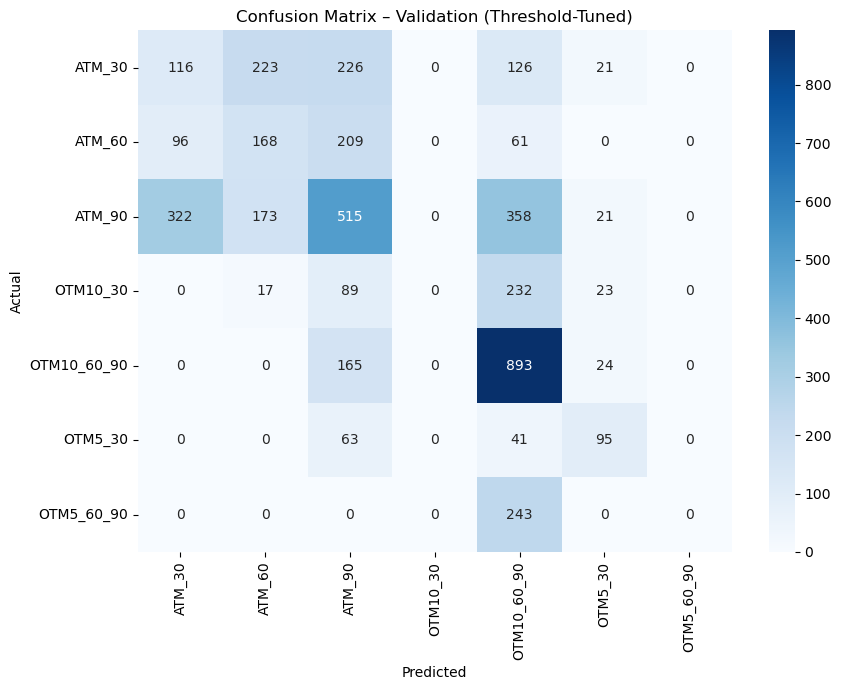

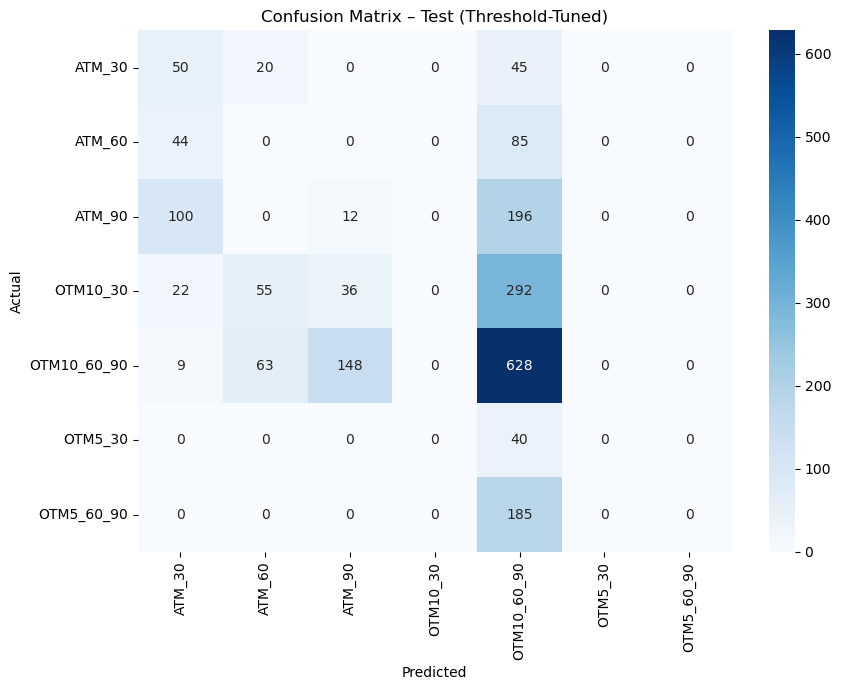

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm   = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_val_true, y_val_pred_tuned, class_names,
                      'Confusion Matrix – Validation (Threshold-Tuned)')
plot_confusion_matrix(y_tst_true, y_tst_pred_tuned, class_names,
                      'Confusion Matrix – Test (Threshold-Tuned)')

## 17. ROC-AUC Curves (One-vs-Rest)

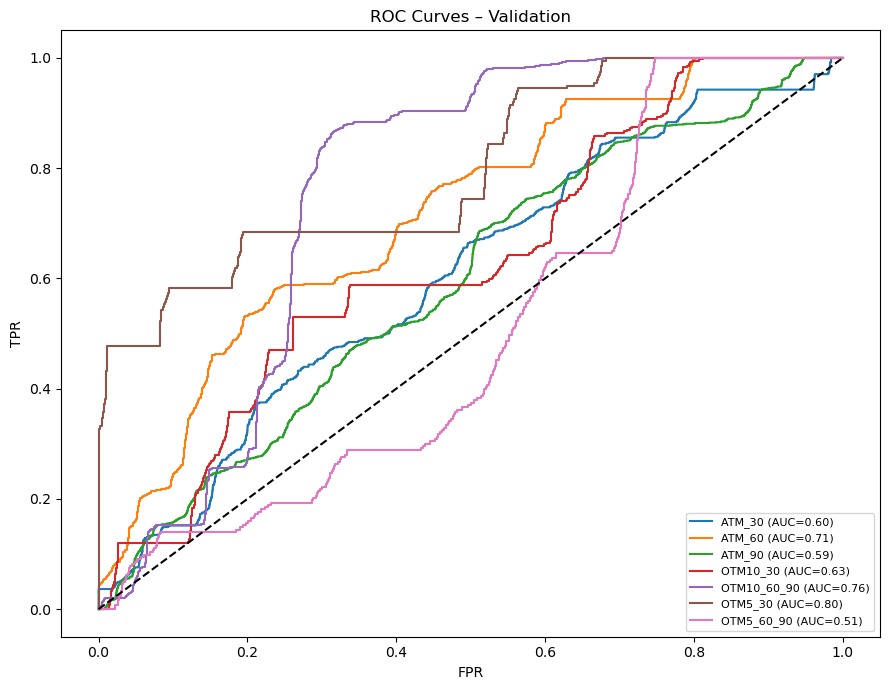

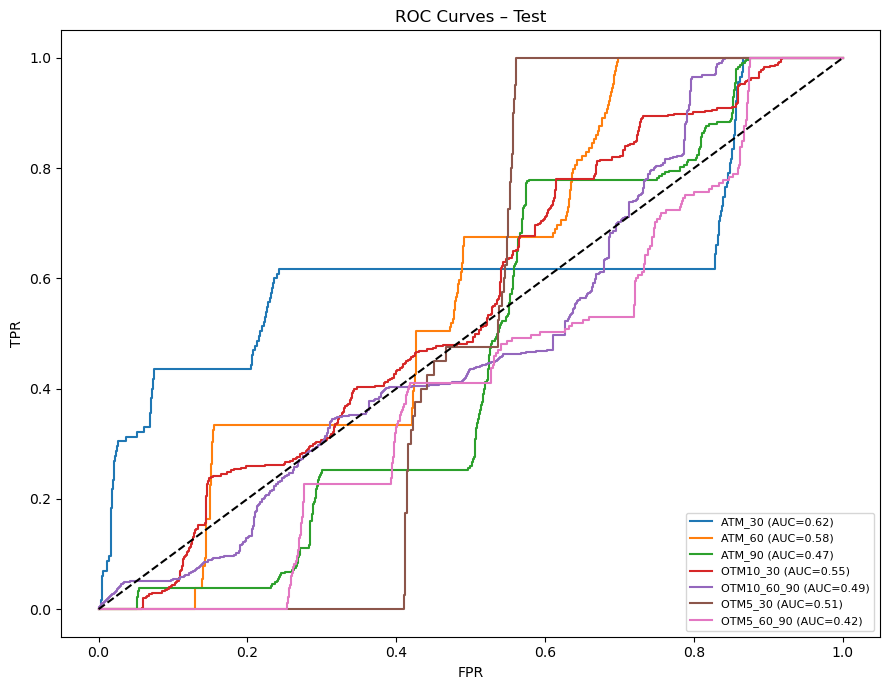

In [ ]:
def plot_roc_curves(y_true, probs, n_classes, class_names, title):
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    fig, ax = plt.subplots(figsize=(9, 7))
    for i, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.show()

plot_roc_curves(y_val_true, y_val_probs, num_classes, class_names,
                'ROC Curves – Validation')
plot_roc_curves(y_tst_true, y_tst_probs, num_classes, class_names,
                'ROC Curves – Test')

## 18. Precision-Recall Curves

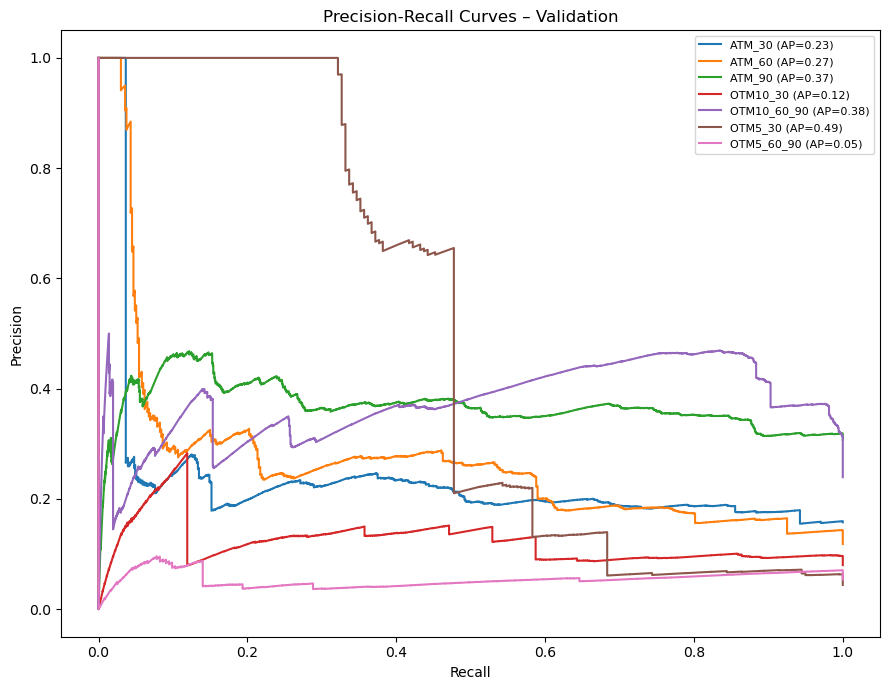

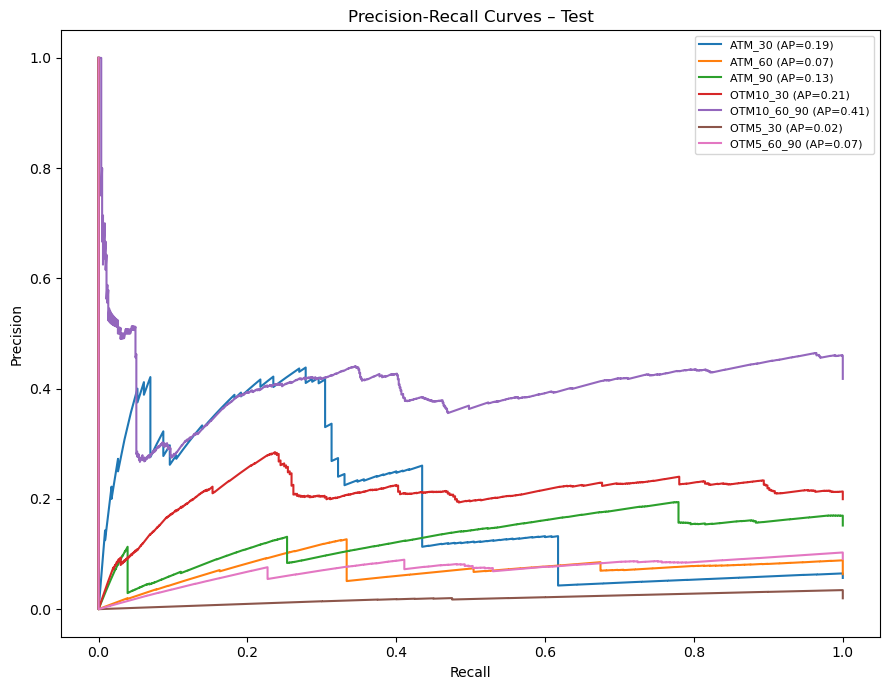

In [ ]:
def plot_pr_curves(y_true, probs, n_classes, class_names, title):
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    fig, ax = plt.subplots(figsize=(9, 7))
    for i, name in enumerate(class_names):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], probs[:, i])
        ap           = average_precision_score(y_bin[:, i], probs[:, i])
        ax.plot(rec, prec, label=f'{name} (AP={ap:.2f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()

plot_pr_curves(y_val_true, y_val_probs, num_classes, class_names,
               'Precision-Recall Curves – Validation')
plot_pr_curves(y_tst_true, y_tst_probs, num_classes, class_names,
               'Precision-Recall Curves – Test')

## 19. Metrics Summary Table

In [ ]:
summary_rows = []
for split, y_true, y_pred_base, y_pred_tuned in [
    ('Validation', y_val_true, y_val_pred_base, y_val_pred_tuned),
    ('Test',       y_tst_true, y_tst_pred_base, y_tst_pred_tuned),
]:
    summary_rows.append({
        'Split'                     : split,
        'Method'                    : 'Argmax',
        'Accuracy'                  : round(accuracy_score(y_true, y_pred_base), 4),
        'Macro-F1'                  : round(f1_score(y_true, y_pred_base, average='macro', zero_division=0), 4),
        'Balanced Accuracy'         : round(balanced_accuracy_score(y_true, y_pred_base), 4),
    })
    summary_rows.append({
        'Split'                     : split,
        'Method'                    : 'Threshold-Tuned',
        'Accuracy'                  : round(accuracy_score(y_true, y_pred_tuned), 4),
        'Macro-F1'                  : round(f1_score(y_true, y_pred_tuned, average='macro', zero_division=0), 4),
        'Balanced Accuracy'         : round(balanced_accuracy_score(y_true, y_pred_tuned), 4),
    })

summary_df = pd.DataFrame(summary_rows)
print('\nMetrics Summary')
display(summary_df)


Metrics Summary


,Split,Method,Accuracy,Macro-F1,Balanced Accuracy
0,Validation,Argmax,0.2998,0.2062,0.2418
1,Validation,Threshold-Tuned,0.3954,0.2800,0.3073
2,Test,Argmax,0.2448,0.0913,0.1635
3,Test,Threshold-Tuned,0.3399,0.1262,0.1735


## 20. Save Model

In [ ]:
MODEL_PATH = MODEL_DIR / 'lstm_cnn_best_model.pth'

torch.save({
    'model_state_dict'  : best_model.state_dict(),
    'best_params'       : best_params,
    'feature_cols'      : feature_cols,
    'seq_len'           : SEQ_LEN,
    'num_classes'       : num_classes,
    'target_classes'    : class_names,
    'tuned_thresholds'  : tuned_thresholds.tolist(),
}, MODEL_PATH)

print(f'Model saved to: {MODEL_PATH}')

# Also save the full model object for convenience
FULL_MODEL_PATH = MODEL_DIR / 'lstm_cnn_full_model.pt'
torch.save(best_model, FULL_MODEL_PATH)
print(f'Full model saved to: {FULL_MODEL_PATH}')

Model saved to: ../saved_models/lstm_cnn_best_model.pth
Full model saved to: ../saved_models/lstm_cnn_full_model.pt


## 21. Inference Helper

In [ ]:
def load_and_predict(model_path, X_new, use_thresholds=True, device=None):
    """
    Load the saved LSTM-CNN model and predict on new sequences.

    Parameters
    ----------
    model_path   : str or Path – path to the .pth checkpoint
    X_new        : np.ndarray  – shape (N, seq_len, n_features)
    use_thresholds : bool      – apply tuned class thresholds
    device       : torch.device or None

    Returns
    -------
    preds      : np.ndarray of int  – predicted class indices
    class_names_pred : list of str  – human-readable class labels
    probs      : np.ndarray         – softmax probabilities (N, num_classes)
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    ckpt = torch.load(model_path, map_location=device)
    p    = ckpt['best_params']

    model = LSTMCNNClassifier(
        n_features=len(ckpt['feature_cols']),
        seq_len=ckpt['seq_len'],
        num_classes=ckpt['num_classes'],
        cnn_out_channels=p['cnn_out_channels'],
        kernel_size=p['kernel_size'],
        lstm_hidden=p['lstm_hidden'],
        lstm_layers=p['lstm_layers'],
        dropout=p['dropout'],
    ).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    x_tensor = torch.tensor(X_new, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(x_tensor)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()

    if use_thresholds and 'tuned_thresholds' in ckpt:
        preds = predict_with_class_thresholds(probs, np.array(ckpt['tuned_thresholds']))
    else:
        preds = probs.argmax(axis=1)

    target_classes = ckpt['target_classes']
    return preds, [target_classes[p] for p in preds], probs


print('load_and_predict helper defined.')
print('\nUsage example:')
print("  preds, labels, probs = load_and_predict('../saved_models/lstm_cnn_best_model.pth', X_new)")

load_and_predict helper defined.

Usage example:
  preds, labels, probs = load_and_predict('../saved_models/lstm_cnn_best_model.pth', X_new)


---
## Summary

| Step | Detail |
|------|--------|
| Data | `daily_stock_optimal_bucket_modeling_with_fred.parquet` |
| Target classes | 7 covered-call buckets (ATM_30/60/90, OTM5_30/60_90, OTM10_30/60_90) |
| Features | Top 35 selected by Random Forest importances |
| Sequence length | 50 trading days (rolling per-symbol window) |
| Train / Val / Test cut | < 2022 / 2022–2023 / ≥ 2024 |
| Imbalance handling | Balanced resampling + class-weighted CrossEntropy |
| Optuna trials | 7 (TPE sampler, maximise val Macro-F1) |
| Architecture | CNN branch (2× Conv1D + BN + Pool) + Bidirectional LSTM → Fusion head |
| Threshold tuning | Per-class greedy search on val set |
| Saved model | `../saved_models/lstm_cnn_best_model.pth` |